Credit Card Fraud Detection - creditcard.csv

In [ ]:
# Reproductibilité (SEED)
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from xgboost import plot_importance

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
    average_precision_score
)

sns.set(style="whitegrid", context="notebook")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/creditcard.csv'

df = pd.read_csv(path)

In [ ]:
# Afficher la taille : (nombre de lignes, nombre de colonnes)
print("Shape:", df.shape)
df.head() # Afficher les 5 premières lignes pour voir la structure des colonne

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#### Identifier target et features

target_col = "Class" # "Class" est la target (0 = normal, 1 = fraude)
feature_cols = [c for c in df.columns if c != target_col] # Toutes les autres colonne sont des features

print("Variable cible (target):", target_col)
print("Nombre de variables explicatives (features):", len(feature_cols))
print("Aperçu des features:", feature_cols[:10], "...")

Variable cible (target): Class
Nombre de variables explicatives (features): 30
Aperçu des features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9'] ...


In [ ]:
#### Déterminer les types de variables
print("Types de chaque colonne :")
print(df.dtypes)

Types de chaque colonne :
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [ ]:
#### Séparation numérique / catégorielle
num_cols = df.select_dtypes(include=["number"]).columns.tolist() # Colonnes numériques
cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist() # Colonnes non numériques

In [ ]:
print("\nVariables numériques:", len(num_cols))
print("Variables catégorielles:", len(cat_cols))
print("Colonnes catégorielles:", cat_cols)


Variables numériques: 31
Variables catégorielles: 0
Colonnes catégorielles: []


In [ ]:
#### Analyse descriptive

# Statistiques globales
# moyenne, écart-type, min, max, quartiles, médiane.
desc = df.describe().T  # .T pour avoir une ligne par variable
desc["median"] = df.median(numeric_only=True)
desc.head(10)

,count,mean,std,min,25%,50%,75%,max,median
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000,84692.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930,0.018109
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729,0.065486
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558,0.179846
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344,-0.019847
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666,-0.054336
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626,-0.274187
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494,0.040103
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208,0.022358
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995,-0.051429


In [ ]:
#### Vérifier valeurs manquantes
missing = df.isnull().sum()
print("Total valeurs manquantes:", missing.sum())
missing[missing > 0]

Total valeurs manquantes: 0


,0


In [ ]:
''' # Methode Pour definir les columns qu'on doit les Keep
from sklearn.feature_selection import SelectKBest, f_classif

# Définir features et target
X = df.drop(columns=["Class"])
y = df["Class"]

# X = features, y = target
selector = SelectKBest(score_func=f_classif, k=6)
X_new = selector.fit_transform(X, y)

# Masque + noms des colonnes sélectionnées
mask = selector.get_support()
selected_feature_names = X.columns[mask]

print("Features sélectionnées :", list(selected_feature_names)) '''

' # Methode Pour definir les columns qu\'on doit les Keep \nfrom sklearn.feature_selection import SelectKBest, f_classif\n\n# Définir features et target\nX = df.drop(columns=["Class"])\ny = df["Class"]\n\n# X = features, y = target\nselector = SelectKBest(score_func=f_classif, k=6)\nX_new = selector.fit_transform(X, y)\n\n# Masque + noms des colonnes sélectionnées\nmask = selector.get_support()\nselected_feature_names = X.columns[mask]\n\nprint("Features sélectionnées :", list(selected_feature_names)) '

In [ ]:
# Sélection d'un sous-ensemble de colonnes (Time Amount Class  V1, V2, V3 )
selected_cols = ["Time", "Amount", "V1", "V2", "V3", "Class"]  # 5 features + target

# Vérification : s'assurer que les colonnes existent
missing_cols = [c for c in selected_cols if c not in df.columns]
if len(missing_cols) > 0:
    print("Colonnes introuvables :", missing_cols)
else:
    df = df[selected_cols].copy()
    print("Colonnes sélectionnées :", selected_cols)
    print("Nouvelle shape :", df.shape)

Colonnes sélectionnées : ['Time', 'Amount', 'V1', 'V2', 'V3', 'Class']
Nouvelle shape : (284807, 6)


In [ ]:
#### Distribution de la target (équilibre des classes)
class_counts = df[target_col].value_counts()
class_ratio = df[target_col].value_counts(normalize=True) * 100

print("Répartition de la cible:\n", class_counts)
print("\nPourcentage:\n", class_ratio)

Répartition de la cible:
 Class
0    284315
1       492
Name: count, dtype: int64

Pourcentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


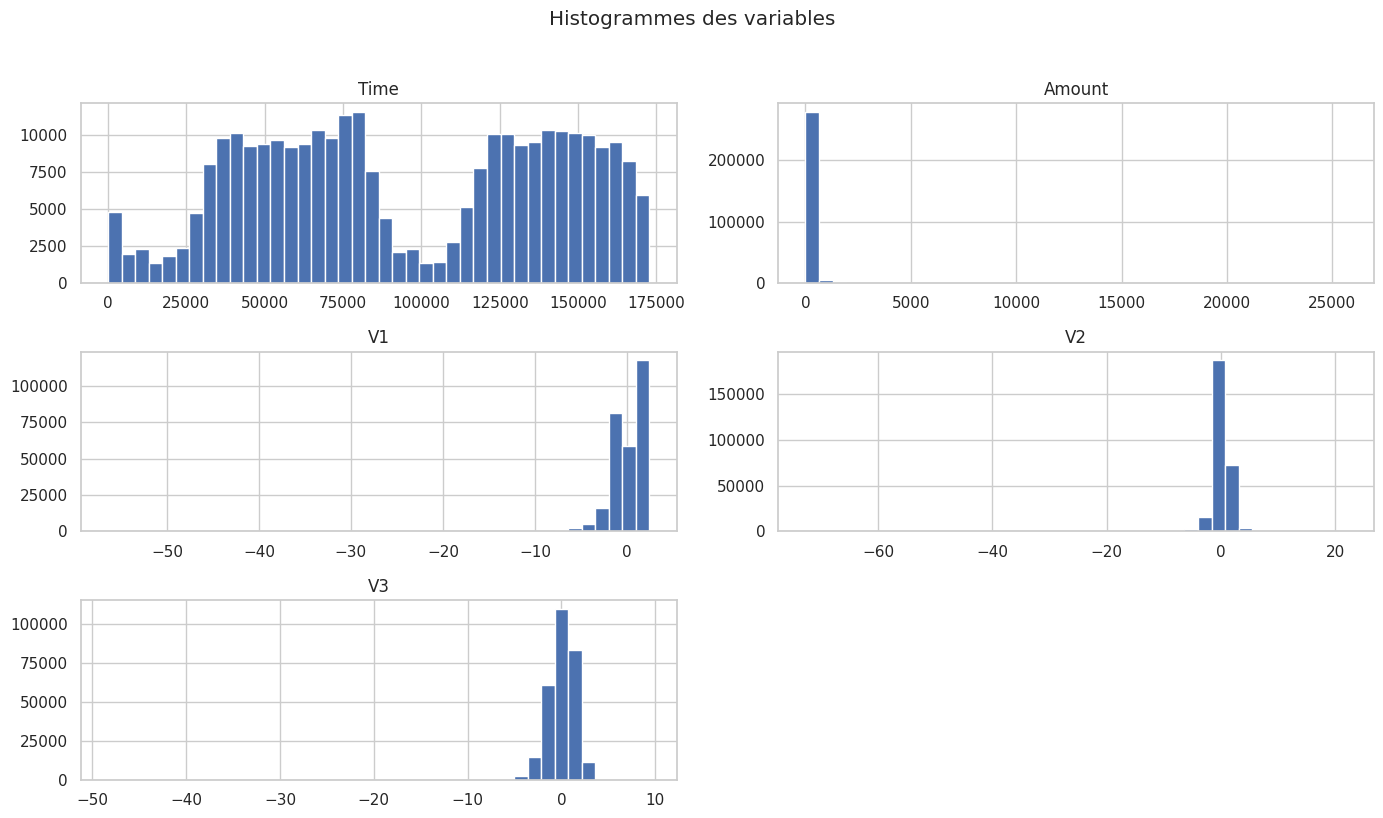

In [ ]:
#### Visualisations

# Histogrammes (variables principales)
cols_to_plot = ["Time", "Amount"] + [f"V{i}" for i in range(1, 4)]
df[cols_to_plot].hist(figsize=(14, 8), bins=40)
plt.suptitle("Histogrammes des variables", y=1.02)
plt.tight_layout()
plt.show()

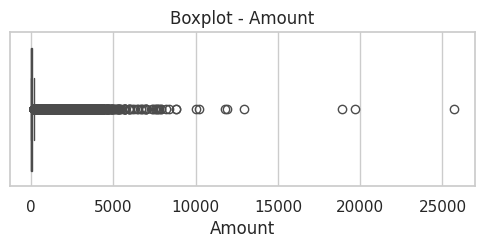

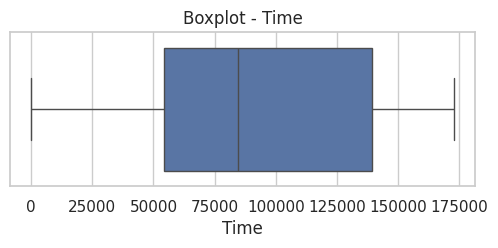

In [ ]:
# Boxplots (détection d’outliers)
plt.figure(figsize=(6, 2))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot - Amount")
plt.show()

plt.figure(figsize=(6, 2))
sns.boxplot(x=df["Time"])
plt.title("Boxplot - Time")
plt.show()

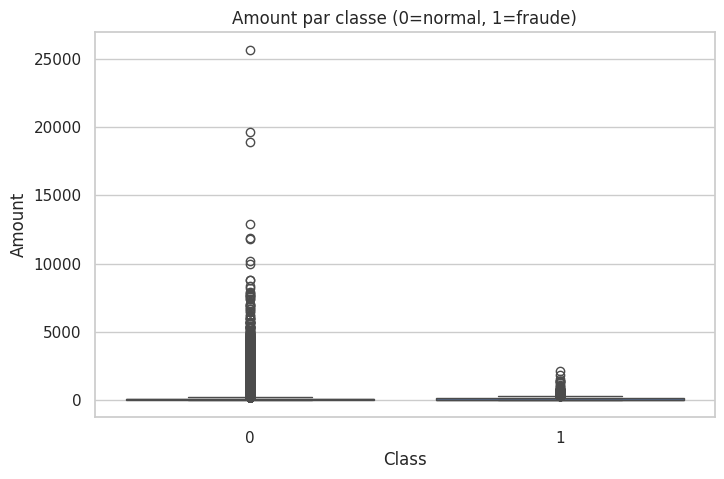

In [ ]:
#  Boxplot par classe
plt.figure(figsize=(8, 5))
sns.boxplot(x=target_col, y="Amount", data=df)
plt.title("Amount par classe (0=normal, 1=fraude)")
plt.show()

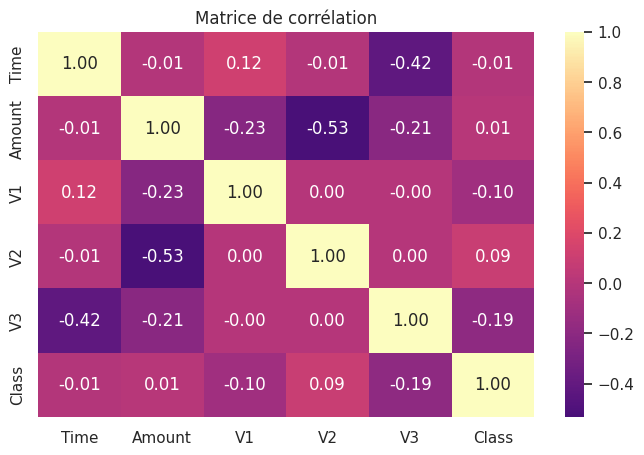

In [ ]:
#### Corrélations
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr,
            annot=True, # afficher les valeurs
            fmt=".2f", # 2 chiffres après virgule
            cmap="magma", # thème couleur
            center=0)
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
# Corrélations avec la cible
corr_target = corr[target_col].sort_values(ascending=False)
print(corr_target.head(6))   # plus corrélées positivement
print(corr_target.tail(6))   # plus corrélées négativement

Class     1.000000
V2        0.091289
Amount    0.005632
Time     -0.012323
V1       -0.101347
V3       -0.192961
Name: Class, dtype: float64
Class     1.000000
V2        0.091289
Amount    0.005632
Time     -0.012323
V1       -0.101347
V3       -0.192961
Name: Class, dtype: float64


Prétraitement

In [ ]:
# Séparer X (features) et y (target)
# prépare les entrées du modèle (X) et la sortie à prédire (y).

target_col = "Class"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (284807, 5)
Shape de y : (284807,)


In [ ]:
# Split train/test AVANT standardisation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test
    random_state=42,      # reproductibilité
    stratify=y            # garder la même proportion de classes dans train/test
)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (227845, 5) | X_test : (56962, 5)


In [ ]:
# Standardisation avec StandardScaler
# StandardScaler = centrage-réduction :
# z = (x - moyenne) / écart-type
# Mettre les variables sur une échelle comparable

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# On apprend moyenne/std sur TRAIN seulement
X_train_scaled = scaler.fit_transform(X_train)

# On applique la même transformation sur TEST
X_test_scaled = scaler.transform(X_test)

# Reconvertir en DataFrame pour garder noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Standardisation terminée.")
print("X_train_scaled shape :", X_train_scaled.shape)
print("X_test_scaled shape  :", X_test_scaled.shape)

Standardisation terminée.
X_train_scaled shape : (227845, 5)
X_test_scaled shape  : (56962, 5)


In [ ]:
# Vérification rapide
# Sur TRAIN, les moyennes doivent être proches de 0
# et les écarts-types proches de 1

print("Moyenne (train) - premières colonnes :")
print(X_train_scaled.mean().head())

print("\nÉcart-type (train) - premières colonnes :")
print(X_train_scaled.std().head())

Moyenne (train) - premières colonnes :
Time     -1.407707e-16
Amount   -2.020811e-17
V1        8.420046e-19
V2       -3.586316e-18
V3        5.675735e-18
dtype: float64

Écart-type (train) - premières colonnes :
Time      1.000002
Amount    1.000002
V1        1.000002
V2        1.000002
V3        1.000002
dtype: float64


In [ ]:
# Traitement final recommandé des outliers pour ce projet
# Décision :
# On ne supprime pas les lignes (pour ne pas perdre des fraudes rares)
# On applique un capping IQR sur les variables numériques

df_final = df.copy() # Copie de travail pour conserver le DataFrame original intact

num_cols = df_final.select_dtypes(include=["number"]).columns.tolist() # Sélection des colonnes numériques
if "Class" in num_cols: # On retire la target " " du traitement des outliers
    num_cols.remove("Class")

# Calcul des quartiles & l'IQR
Q1 = df_final[num_cols].quantile(0.25)
Q3 = df_final[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ramene les valeur extrêmes aux bornes IQR
df_final[num_cols] = df_final[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

print("Traitement outliers terminé avec IQR capping (sans suppression de lignes).")
print("Shape final :", df_final.shape)

Traitement outliers terminé avec IQR capping (sans suppression de lignes).
Shape final : (284807, 6)


In [ ]:
#Verification des resultat

print("Shape avant :", df.shape)
print("Shape après :", df_final.shape)

Shape avant : (284807, 6)
Shape après : (284807, 6)


In [ ]:
# Recalcul des bornes sur le df original
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "Class" in num_cols:
    num_cols.remove("Class")

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Compter les valeurs encore hors bornes dans df_final
out_of_bounds = ((df_final[num_cols] < lower_bound) | (df_final[num_cols] > upper_bound)).sum().sum()
print("Nombre de valeurs hors bornes après capping :", out_of_bounds)

Nombre de valeurs hors bornes après capping : 0


In [ ]:
# Nombre de cellules modifiées par le capping
changed_cells = (df[num_cols] != df_final[num_cols]).sum().sum()
print("Nombre total de valeurs modifiées par capping :", changed_cells)

Nombre total de valeurs modifiées par capping : 55855


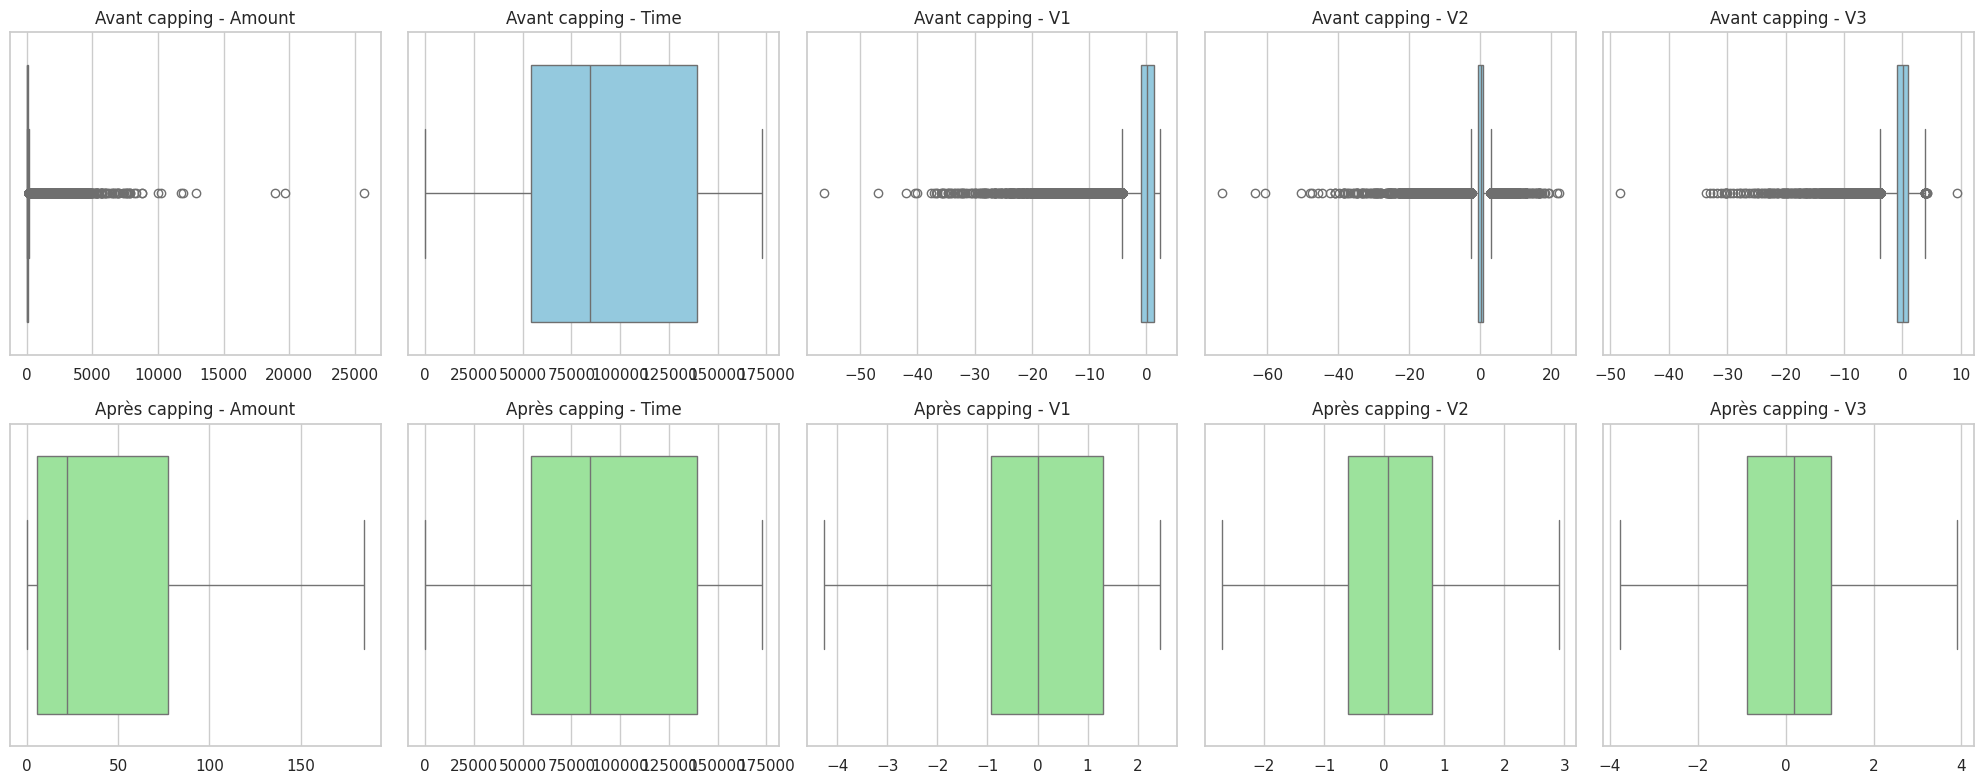

In [ ]:
#  Vérification visuelle : Boxplots avant vs après capping

# Colonnes à visualiser
cols_to_plot = ["Amount", "Time", "V1", "V2", "V3"]

# Création d'une figure avec 2 lignes

fig, axes = plt.subplots(2, len(cols_to_plot), figsize=(4*len(cols_to_plot), 8))

for i, col in enumerate(cols_to_plot):
    # Avant
    sns.boxplot(x=df[col], ax=axes[0, i], color="skyblue")
    axes[0, i].set_title(f"Avant capping - {col}")
    axes[0, i].set_xlabel("")

    # Après
    sns.boxplot(x=df_final[col], ax=axes[1, i], color="lightgreen")
    axes[1, i].set_title(f"Après capping - {col}")
    axes[1, i].set_xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
# Modeles a implimenter : Arbre de décision, Forêt aléatoire , SVM , XGBoost
# Préparer les données (X, y)

target_col = "Class"
# X = features, y = target
X = df_final.drop(columns=[target_col]).copy()
y = df_final[target_col].copy()

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (284807, 5)
Shape y : (284807,)


In [ ]:
# Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # fixe pour reproductibilité
    stratify=y # garder meme proportion des classes
)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("y_train :", y_train.shape, "| y_test :", y_test.shape)

X_train : (227845, 5) | X_test : (56962, 5)
y_train : (227845,) | y_test : (56962,)


In [ ]:
# Standardisation (StandardScaler)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # Fit sur train uniquement (éviter data leakage)
X_test_scaled  = scaler.transform(X_test)

# Revenir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(" Standardisation Done ")

 Standardisation Done 


In [ ]:
# dictionnaires pour stocker résultats
best_models = {}
best_params = {}

In [ ]:
# Grid Search - Decision Tree

grid_dt = GridSearchCV(
    estimator=models_and_params["Decision Tree"]["model"],
    param_grid=models_and_params["Decision Tree"]["params"],
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_scaled, y_train)

best_models["Decision Tree"] = grid_dt.best_estimator_
best_params["Decision Tree"] = grid_dt.best_params_

print(" Decision Tree done")
print("Best params:", grid_dt.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
 Decision Tree done
Best params: {'max_depth': None, 'min_samples_split': 10}


In [ ]:
# Grid Search - Random Forest

grid_rf = GridSearchCV(
    estimator=models_and_params["Random Forest"]["model"],
    param_grid=models_and_params["Random Forest"]["params"],
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_models["Random Forest"] = grid_rf.best_estimator_
best_params["Random Forest"] = grid_rf.best_params_

print("Random Forest done")
print("Best params:", grid_rf.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest done
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# Grid Search - SVM (MINIMIZED)

svm_small_params = {
    "C": [1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale"]
}

grid_svm = GridSearchCV(
    estimator=models_and_params["SVM"]["model"],
    param_grid=svm_small_params,
    scoring="average_precision",
    cv=2,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)

best_models["SVM"] = grid_svm.best_estimator_
best_params["SVM"] = grid_svm.best_params_

print(" SVM done")
print("Best params:", grid_svm.best_params_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
 SVM done
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# Grid Search - XGBoost (MINIMIZED)

xgb_small_params = {
    "n_estimators": [100],
    "max_depth": [4, 6],
    "learning_rate": [0.1]
}

grid_xgb = GridSearchCV(
    estimator=models_and_params["XGBoost"]["model"],
    param_grid=xgb_small_params,
    scoring="average_precision",
    cv=2,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_scaled, y_train)

best_models["XGBoost"] = grid_xgb.best_estimator_
best_params["XGBoost"] = grid_xgb.best_params_

print(" XGBoost done")
print("Best params:", grid_xgb.best_params_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
 XGBoost done
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


In [ ]:
# Entraînement final avec meilleurs modèles
trained_models = {}

for name, model in best_models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f" {name} entraîné")

print("Modèles entraînés :", list(trained_models.keys()))

 Decision Tree entraîné
 Random Forest entraîné
 SVM entraîné
 XGBoost entraîné
Modèles entraînés : ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost']


In [ ]:
# Decision Tree - Évaluation
model_dt = trained_models["Decision Tree"]

y_pred_dt = model_dt.predict(X_test_scaled)
y_score_dt = model_dt.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree")
print("Accuracy          :", accuracy_score(y_test, y_pred_dt))
print("Precision         :", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall            :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1-score          :", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC AUC           :", roc_auc_score(y_test, y_score_dt))
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred_dt))
print("MCC               :", matthews_corrcoef(y_test, y_pred_dt))
print("PR AUC            :", average_precision_score(y_test, y_score_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree
Accuracy          : 0.9974017766230119
Precision         : 0.3310810810810811
Recall            : 0.5
F1-score          : 0.3983739837398374
ROC AUC           : 0.7493974165355507
Balanced Accuracy : 0.7491295019696117
MCC               : 0.4056284007431449
PR AUC            : 0.302077605589128
Confusion Matrix:
 [[56765    99]
 [   49    49]]


In [ ]:
# Random Forest - Évaluation
model_rf = trained_models["Random Forest"]

y_pred_rf = model_rf.predict(X_test_scaled)
y_score_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest")
print("Accuracy          :", accuracy_score(y_test, y_pred_rf))
print("Precision         :", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall            :", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1-score          :", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC AUC           :", roc_auc_score(y_test, y_score_rf))
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred_rf))
print("MCC               :", matthews_corrcoef(y_test, y_pred_rf))
print("PR AUC            :", average_precision_score(y_test, y_score_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy          : 0.9988588883817282
Precision         : 0.8367346938775511
Recall            : 0.41836734693877553
F1-score          : 0.5578231292517006
ROC AUC           : 0.9110961492081358
Balanced Accuracy : 0.7091133301942049
MCC               : 0.5912071470046483
PR AUC            : 0.559027949258365
Confusion Matrix:
 [[56856     8]
 [   57    41]]


In [ ]:
# SVM - Évaluation
model_svm = trained_models["SVM"]

y_pred_svm = model_svm.predict(X_test_scaled)
y_score_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

print("SVM")
print("Accuracy          :", accuracy_score(y_test, y_pred_svm))
print("Precision         :", precision_score(y_test, y_pred_svm, zero_division=0))
print("Recall            :", recall_score(y_test, y_pred_svm, zero_division=0))
print("F1-score          :", f1_score(y_test, y_pred_svm, zero_division=0))
print("ROC AUC           :", roc_auc_score(y_test, y_score_svm))
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred_svm))
print("MCC               :", matthews_corrcoef(y_test, y_pred_svm))
print("PR AUC            :", average_precision_score(y_test, y_score_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM
Accuracy          : 0.9555317580141147
Precision         : 0.028648857917150602
Recall            : 0.7551020408163265
F1-score          : 0.05520328235732935
ROC AUC           : 0.8696108437747637
Balanced Accuracy : 0.8554896107289286
MCC               : 0.1416155156133787
PR AUC            : 0.0447775258307729
Confusion Matrix:
 [[54355  2509]
 [   24    74]]


In [ ]:
# XGBoost - Évaluation
model_xgb = trained_models["XGBoost"]

y_pred_xgb = model_xgb.predict(X_test_scaled)
y_score_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

print("XGBoost")
print("Accuracy          :", accuracy_score(y_test, y_pred_xgb))
print("Precision         :", precision_score(y_test, y_pred_xgb, zero_division=0))
print("Recall            :", recall_score(y_test, y_pred_xgb, zero_division=0))
print("F1-score          :", f1_score(y_test, y_pred_xgb, zero_division=0))
print("ROC AUC           :", roc_auc_score(y_test, y_score_xgb))
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred_xgb))
print("MCC               :", matthews_corrcoef(y_test, y_pred_xgb))
print("PR AUC            :", average_precision_score(y_test, y_score_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost
Accuracy          : 0.9986833327481479
Precision         : 0.8285714285714286
Recall            : 0.29591836734693877
F1-score          : 0.43609022556390975
ROC AUC           : 0.9626976969037474
Balanced Accuracy : 0.6479064262170822
MCC               : 0.4947156044588986
PR AUC            : 0.4701128979650334
Confusion Matrix:
 [[56858     6]
 [   69    29]]


In [ ]:
# Overfitting / Underfitting

print("=== Vérification Overfitting / Underfitting (F1 train vs test) ===")
for name, model in trained_models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred  = model.predict(X_test_scaled)

    f1_train = f1_score(y_train, y_train_pred, zero_division=0)
    f1_test  = f1_score(y_test, y_test_pred, zero_division=0)
    gap = f1_train - f1_test

    print(f"{name:15} | F1 train: {f1_train:.4f} | F1 test: {f1_test:.4f} | Gap: {gap:.4f}")

=== Vérification Overfitting / Underfitting (F1 train vs test) ===
Decision Tree   | F1 train: 0.7665 | F1 test: 0.3984 | Gap: 0.3682
Random Forest   | F1 train: 1.0000 | F1 test: 0.5578 | Gap: 0.4422
SVM             | F1 train: 0.0738 | F1 test: 0.0552 | Gap: 0.0186
XGBoost         | F1 train: 0.5441 | F1 test: 0.4361 | Gap: 0.1081


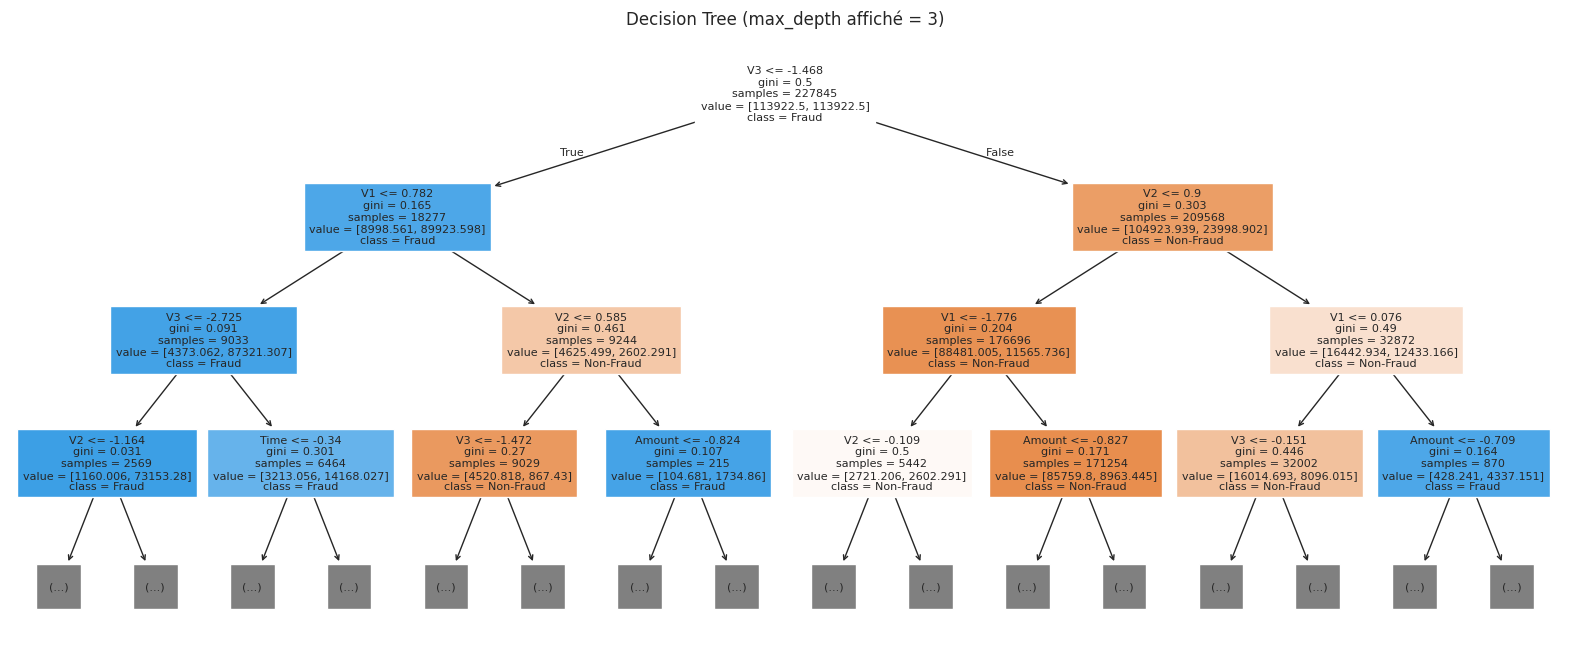

In [ ]:
# Visualiser Decision Tree

plt.figure(figsize=(20, 8))
plot_tree(
    trained_models["Decision Tree"],
    feature_names=X_train.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    max_depth=3,   # pour garder le graphe lisible
    fontsize=8
)
plt.title("Decision Tree (max_depth affiché = 3)")
plt.show()

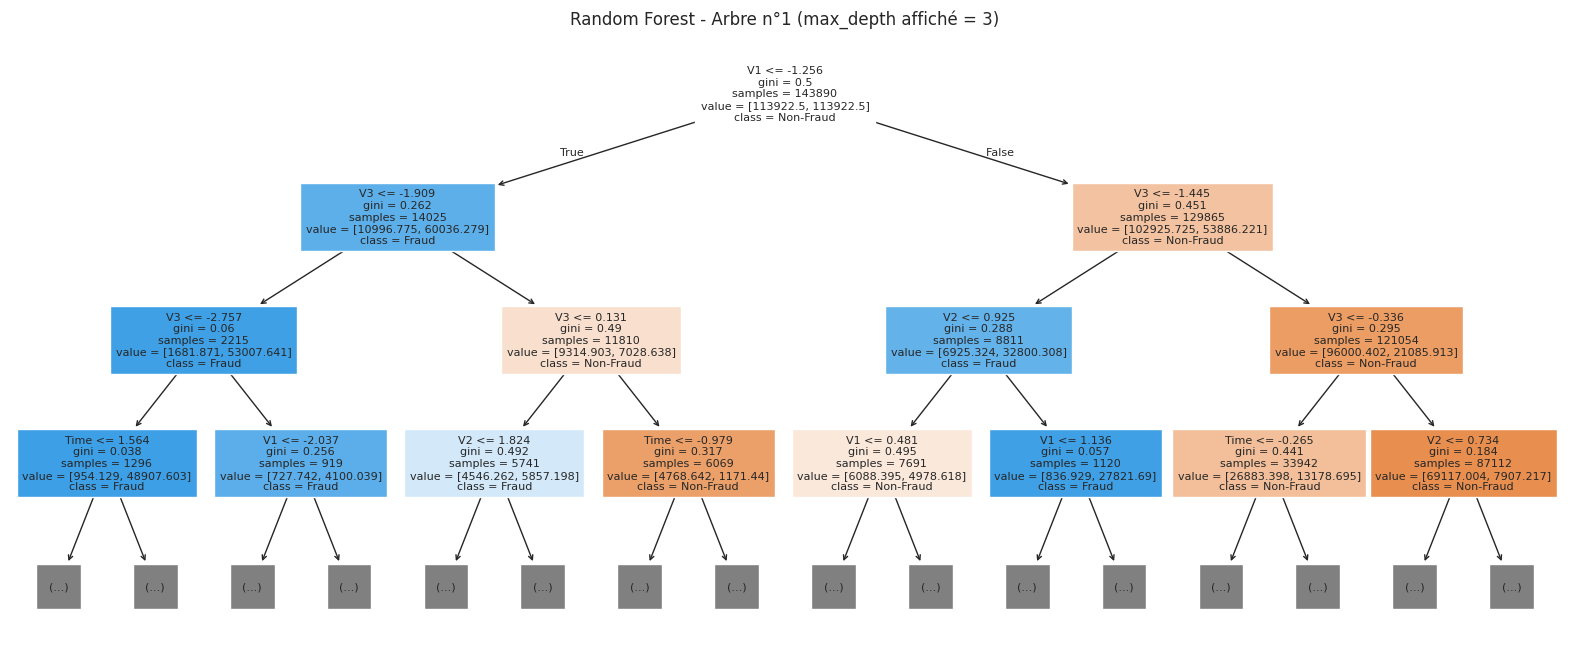

In [ ]:
# Visualiser Random Forest (un arbre de la forêt)
# on affiche le 1er
rf_model = trained_models["Random Forest"]
one_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(
    one_tree,
    feature_names=X_train.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Random Forest - Arbre n°1 (max_depth affiché = 3)")
plt.show()

<Figure size 800x600 with 0 Axes>

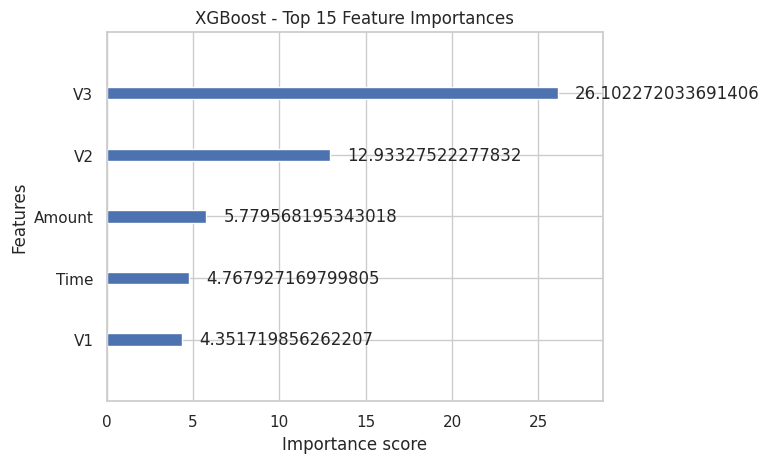

In [ ]:
# 4) Visualiser XGBoost (Feature Importance)

xgb_model = trained_models["XGBoost"]

plt.figure(figsize=(8,6))
plot_importance(xgb_model, max_num_features=15, importance_type="gain")
plt.title("XGBoost - Top 15 Feature Importances")
plt.show()